# Deepfake detection QML

## Environment

Follow the ISAMBARD documentation to [create a custom Jupyter kernel](https://docs.isambard.ac.uk/user-documentation/guides/jupyter/#use-a-custom-jupyter-kernel-in-a-jupyterlab-session) based on `requirements.yaml`.

## Imports

In [1]:
import os
import logging
import shutil
import torch

from deepfake_detection import utils, data, train, eval, factory, visualise
from deepfake_detection.devices import classic_device

## Define "CLI" params

In [2]:
# CLI params
config_path = "./Deepfake.conf.yaml" # Path to config YAML file
mode = "train_infer"                 # Execution mode: "train", "infer", or "train_infer"
download = False                     # True = download and sort data
sort = False                         # True = re-sorts pre-downloaded data
backbone_path = None                 # Path to off-the-shelf model weights (offline)
weights_path = None                  # Path to pre-trained model weights (infer)
data_path = "./data"                 # Dataset directory
outputs_path = "./outputs"           # Output directory
kaggle_path = "/tmp"                 # Kaggle cache directory

## Setup

In [3]:
# Set Kaggle cache
os.environ["KAGGLEHUB_CACHE"] = kaggle_path

# Load and validate config
config = utils.check_config(utils.load_yaml(config_path))

# Set up session-specific outputs directory
datasets = "_".join(config["trainData"].keys())

session_name = f"{config['modelType']}_bs{config['batchSize']}_ep{config['numEpochs']}_{datasets}_{mode}"

if torch.cuda.is_available() and config["nGPUs"] > 0:
    session_name += f"_gpu{config['nGPUs']}"

outputs_path = os.path.join(outputs_path, session_name)
utils.check_path(outputs_path)

# Make a copy of the configuration
try:
    shutil.copyfile(config_path, os.path.join(outputs_path, f"{session_name}.conf.yaml"))
except shutil.SameFileError:
    pass

# Configure logging
utils.setup_log(outputs_path, session_name, "info")
logging.info("Loaded configuration: %s", config)

# Set seed for reproducibility
seed = config["manualSeed"]
torch.manual_seed(seed)
logging.info("Seed: %s", seed)

outputs_path

2026-02-20 11:48:27 INFO     Loaded configuration: {'modelType': 'Classic', 'trainData': {'deepfake2k': 'ciplab/real-and-fake-face-detection'}, 'testData': {'hard1k': 'hamzaboulahia/hardfakevsrealfaces'}, 'batchSize': 32, 'imageHeight': 64, 'imageWidth': 64, 'numEpochs': 10, 'patience': 0, 'manualSeed': 999, 'numWorkers': 2, 'numChannels': 3, 'learningRate': 0.0002, 'beta1': 0.5, 'nGPUs': 0, 'nCPUs': 4, 'quantumDevice': 'default.qubit', 'nQubits': 4, 'diffType': 'best', 'nLayers': 6, 'typeLayers': 'strong', 'patch': False, 'optimisationLevel': 1, 'shots': 1024, 'split': {'train': 0.8, 'val': 0.2, 'test': 0.0}}
2026-02-20 11:48:27 INFO     Seed: 999


'./outputs/Classic_bs32_ep10_deepfake2k_train_infer'

## Create device and model

In [4]:
# Create device
device = classic_device.ClassicDevice(config["nGPUs"]).device
logging.info("Device type: %s", device.type)

# Create model
model = factory.create_model(
    config,
    backbone_path=backbone_path,
    weights_path=weights_path,
    device=device
)

## Parallelise data processing
if device.type == "cuda" and config["nGPUs"] > 1:
    model = torch.nn.DataParallel(model, list(range(config["nGPUs"])))

model

2026-02-20 11:48:27 INFO     Device type: cpu


ClassicalModel(
  (pretrainedmodel): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

## Download and sort data (optional)

In [5]:
if config.get("trainData", None):
    train_path = os.path.join(data_path, "train")
    data.download_and_sort(config["trainData"], train_path, download, sort)

if config.get("testData", None):
    test_path = os.path.join(data_path, "test")
    data.download_and_sort(config["testData"], test_path, download, sort)

## Prepare Datasets

In [6]:
datasets = data.prepare_datasets(config, mode, data_path, seed, model)

datasets

2026-02-20 11:48:28 INFO     Loading data
2026-02-20 11:48:28 INFO     Loading data
2026-02-20 11:48:28 INFO     Dataset split: train=1632, val=408, test=1289 images


{'train': <torch.utils.data.dataloader.DataLoader at 0x11e1b2e40>,
 'validate': <torch.utils.data.dataloader.DataLoader at 0x11e1c2d50>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x11e1c3d90>}

## Train (if enabled)

In [7]:
if "train" in mode:
    logging.info("--STARTING TRAINING--")
    train_metrics = train.train(
        device, model, datasets["train"], datasets["validate"],
        config["numEpochs"], config["learningRate"], config["patience"],
        os.path.join(outputs_path, session_name)
    )

    # Save CSV
    utils.save_results(
        train_metrics,
        f"{os.path.join(outputs_path, session_name)}.csv"
    )

    # Save visualization
    visualise.detailed_plot(
        train_metrics,
        f"{os.path.join(outputs_path, session_name)}_metrics.png"
    )

2026-02-20 11:48:28 INFO     --STARTING TRAINING--
2026-02-20 11:49:30 INFO     Epoch: 1  Train Loss: 0.7007  Train Acc: 55.45%  Train F1: 0.5716  Val Loss: 0.6856  Val Acc: 58.33%  Val F1: 0.6458  Mem: 480MB  CPU: 40.84%  
2026-02-20 11:49:30 INFO     Validation metrics improved. Model saved.
2026-02-20 11:50:29 INFO     Epoch: 2  Train Loss: 0.6482  Train Acc: 63.91%  Train F1: 0.6570  Val Loss: 0.6930  Val Acc: 55.39%  Val F1: 0.5748  Mem: 425MB  CPU: 41.65%  
2026-02-20 11:50:29 INFO     Validation metrics degraded for 1 epochs.
2026-02-20 11:50:29 INFO     Early stopping triggered after 2 epochs.
2026-02-20 11:50:29 INFO     TRAINING RESULTS  Avg Train Loss: 0.6744  Avg Train Acc: 59.68%  Avg Train F1: 0.6143  Avg Val Loss: 0.6893  Avg Val Acc: 56.86%  Avg Val F1: 0.6103  Avg Mem: 452MB  Avg CPU: 41.25%  
2026-02-20 11:50:29 INFO     Best accuracy: 58.33%
2026-02-20 11:50:29 INFO     Training visualization saved to ./outputs/Classic_bs32_ep10_deepfake2k_train_infer/Classic_bs32_ep

## Evaluate (if enabled)

In [ ]:
if "infer" in mode:
    logging.info("--STARTING INFERENCE--")
    eval_metrics = eval.eval_model(model, device, datasets["test"])

    # Log results
    avg_mem_util = sum(eval_metrics["mem_utils"]) / len(eval_metrics["mem_utils"]) if eval_metrics["mem_utils"] else 0
    avg_cpu_util = sum(eval_metrics["cpu_utils"]) / len(eval_metrics["cpu_utils"]) if eval_metrics["cpu_utils"] else 0
    avg_gpu_util = sum(eval_metrics["gpu_utils"]) / len(eval_metrics["gpu_utils"]) if eval_metrics["gpu_utils"] else 0

    log_msg = (
        "INFERENCE RESULTS  "
        f"Avg Eval Acc: {eval_metrics["eval_acc"]:.2f}%  "
        f"Avg Eval F1: {eval_metrics["eval_f1"]:.4f}  "
        f"Avg Mem: {avg_mem_util:.0f}MB  "
        f"Avg CPU: {avg_cpu_util:.2f}%  "
    )

    if eval_metrics["gpu_utils"]:
        log_msg += f"Avg GPU: {avg_gpu_util:.2f}%  "

    logging.info(log_msg)

2026-02-20 11:50:29 INFO     --STARTING INFERENCE--
2026-02-20 11:50:53 INFO     INFERENCE RESULTS  Avg Eval Acc: 75.41%  Avg Eval F1: 0.7636  Avg Mem: 273MB  Avg CPU: 39.75%  


## Check metrics

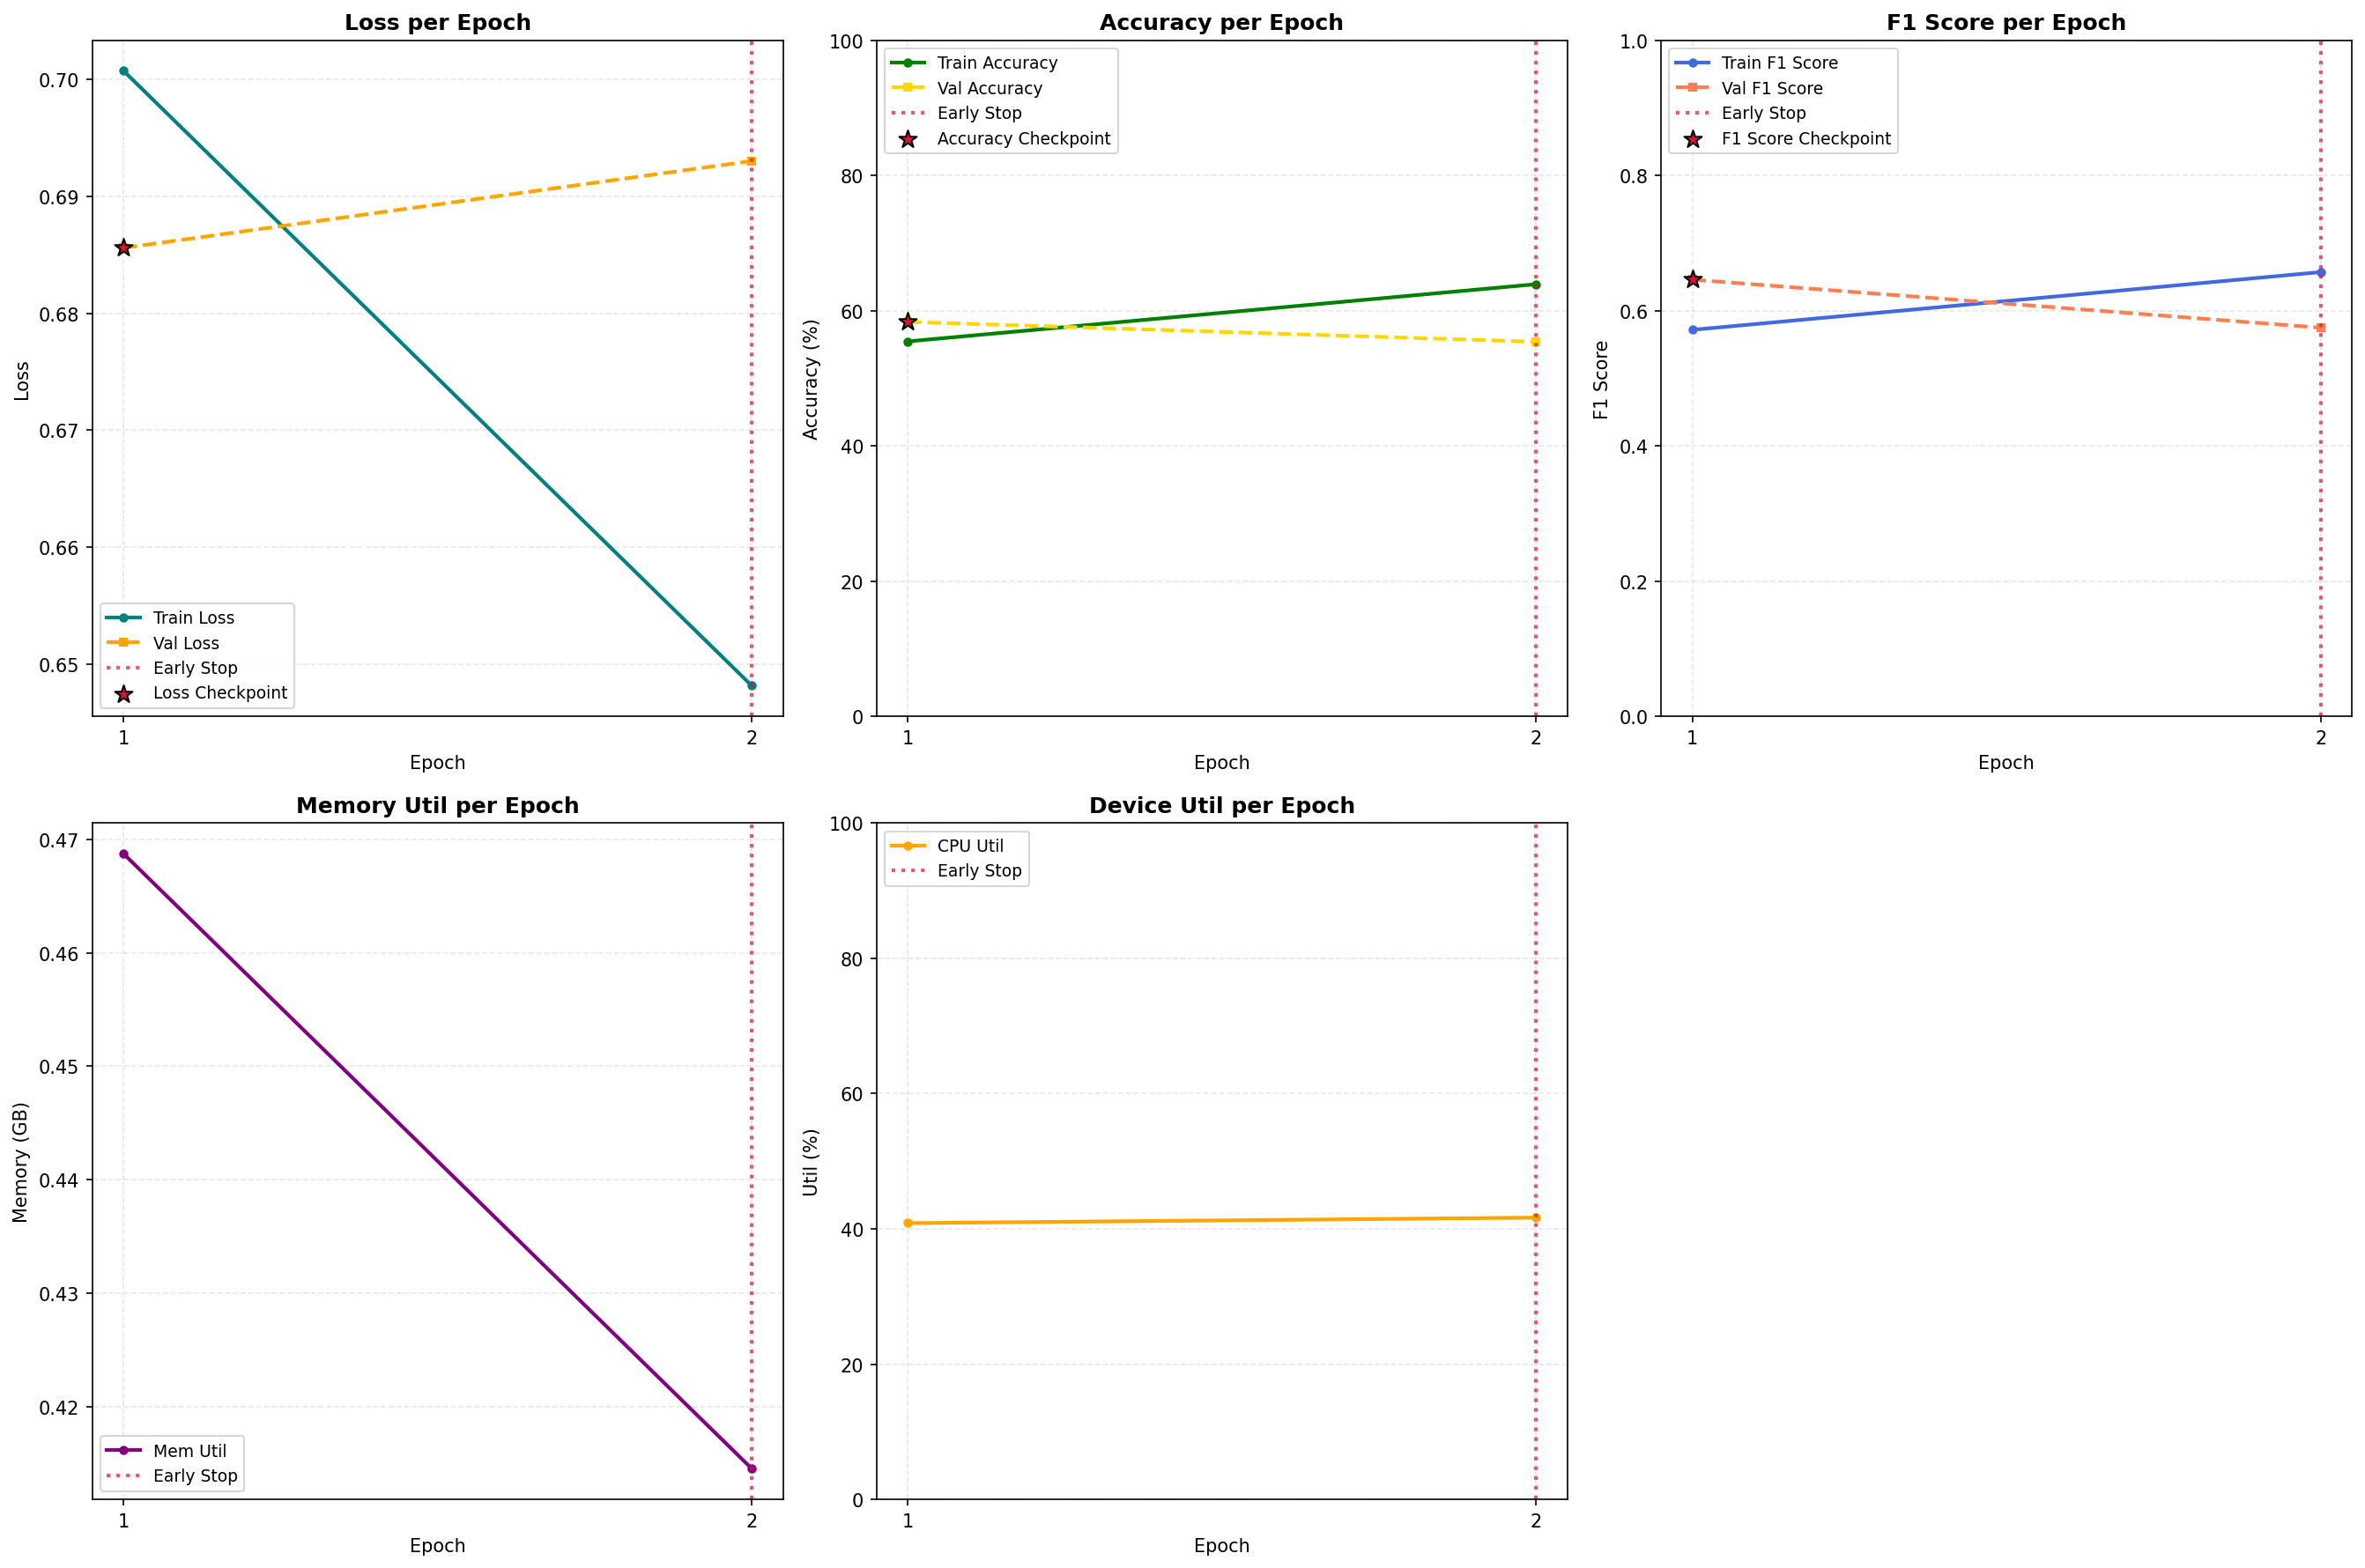

In [9]:
from IPython.display import Image, display
display(Image(filename=os.path.join(outputs_path, f"{session_name}_metrics.png")))

## Show predictions

2026-02-20 11:51:06 INFO     Predictions visualisation saved to ./outputs/Classic_bs32_ep10_deepfake2k_train_infer/Classic_bs32_ep10_deepfake2k_train_infer_predictions.png


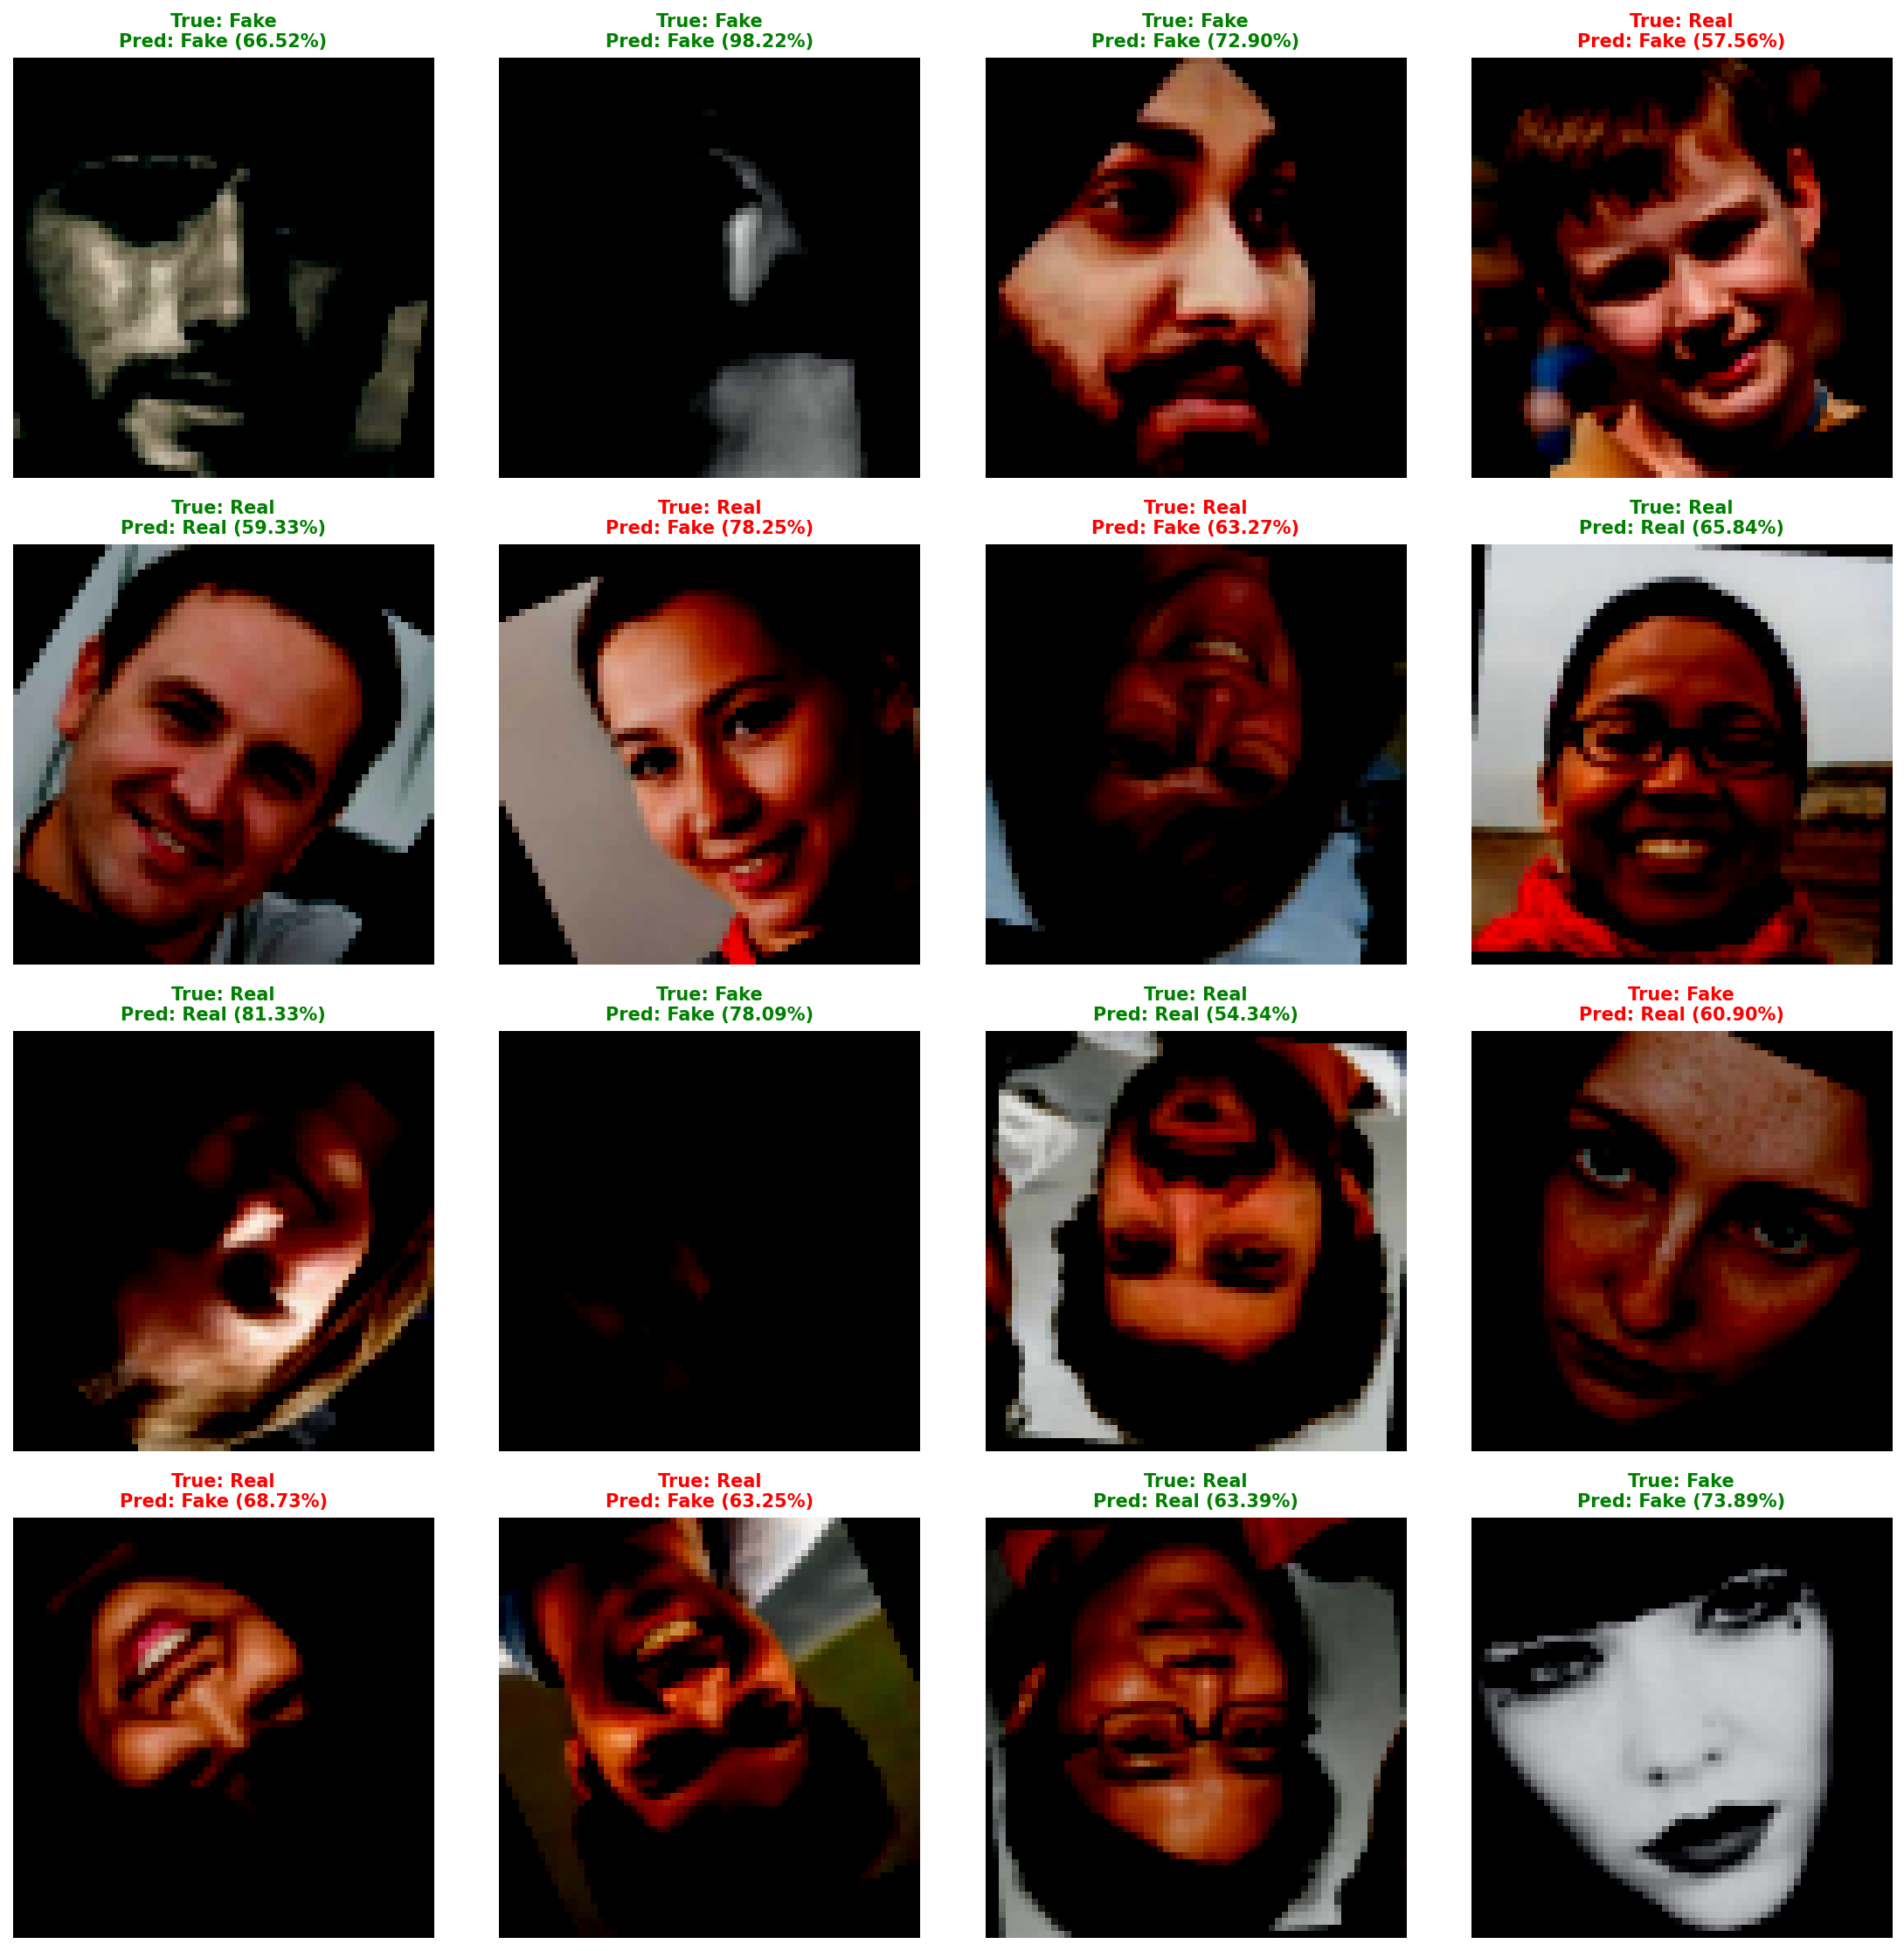

In [10]:
# Save visualization
visualise.show_predictions(
    model, datasets["test"], device,
    f"{os.path.join(outputs_path, session_name)}_predictions.png"
)

display(Image(filename=os.path.join(outputs_path, f"{session_name}_predictions.png")))

## Make a copy of the notebook

In [11]:
try:
    shutil.copyfile("Deepfake.ipynb", os.path.join(outputs_path, f"{session_name}.ipynb"))
except shutil.SameFileError:
    pass